# 06 - ML: Delivery Delay Prediction
## Olist Brazilian E-Commerce

---

## Business Justification

**Problem:** 6.73% of orders on the Olist platform are delivered late.
At 96,178 orders in the SLA-eligible base, that is 6,477 late deliveries.
Late deliveries directly correlate with lower review scores (High Risk sellers
average 3.62 vs Strong Performers at 4.20).

**Business question:** Can we predict at order placement time whether an order
is likely to be delivered late — so the platform can intervene proactively?

**Intervention options if prediction is available:**
- Flag high-risk orders for seller outreach before dispatch
- Set conservative delivery estimates for customers on high-risk orders
- Trigger automated alerts to logistics partners

**Why classification, not regression:**
The business decision is binary — intervene or don't. A regression model
predicting exact delay days is harder to act on operationally. A binary
classifier with a tunable threshold gives the operations team a direct
action trigger.

**Why Random Forest (primary model):**
- Handles mixed feature types (numeric + categorical) without extensive preprocessing
- Robust to the moderate correlation between weight and volume features
- Feature importance is directly interpretable for business stakeholders
- Proven performance on tabular imbalanced classification problems

**Why Logistic Regression (baseline):**
- Fast to train, fully interpretable coefficients
- Establishes a minimum AUC threshold the primary model must beat
- If Random Forest doesn't outperform Logistic Regression meaningfully,
  the added complexity is not justified

**Class imbalance handling:**
Target variable is_late has 6.73% positive class (14:1 ratio).
Using class_weight='balanced' in both models — adjusts the loss function
to penalise misclassification of the minority class proportionally.
No resampling (SMOTE etc.) — class_weight is sufficient for Random Forest
on this imbalance ratio and avoids introducing synthetic data artefacts.

**Success criteria:**
- Minimum AUC-ROC: 0.70 (below this the model is not operationally useful)
- Primary metric: AUC-ROC (robust to class imbalance)
- Secondary metrics: Precision, Recall, F1 for positive class (is_late=True)
- If AUC < 0.60 after diagnosis: document failure, explain why, do not proceed

**Feature dropped pre-training:**
avg_item_price removed (r=0.933 with order_value — multicollinearity check
in 04_eda.ipynb Chart 9).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from urllib.parse import quote_plus
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             confusion_matrix, ConfusionMatrixDisplay)
import joblib

# --- Paths ---
SAVE_PATH  = r"D:\DataAnalyticsProjects\ecommerce-retail-analysis\reports\figures"
MODEL_PATH = r"D:\DataAnalyticsProjects\ecommerce-retail-analysis\ml\models"

# --- DB connection ---
load_dotenv()
DB_PASS = os.getenv("DB_PASSWORD")
DB_USER = os.getenv("DB_USER", "postgres")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "olist_ecommerce")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{quote_plus(DB_PASS)}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM olist.v_delivery_delay_drivers"))
    print(f"✅ Connected. Feature view rows: {result.fetchone()[0]:,}")

✅ Connected. Feature view rows: 96,192


In [2]:
# Load full feature set from view
# avg_item_price excluded (multicollinearity — see 04_eda.ipynb Chart 9)
# approval_lag_hours nulls excluded via WHERE (14 rows dropped, documented)

query = """
SELECT
    is_late,
    order_day_of_week,
    order_hour,
    order_month_num,
    item_count,
    seller_count,
    order_value,
    freight_value,
    freight_ratio_pct,
    avg_product_weight_g,
    avg_product_volume_cm3,
    seller_hist_late_rate,
    seller_avg_days_to_deliver,
    seller_total_orders,
    customer_state,
    primary_category,
    approval_lag_hours
FROM olist.v_delivery_delay_drivers
WHERE approval_lag_hours IS NOT NULL
"""

df = pd.read_sql(query, engine)

print(f"Rows loaded       : {len(df):,}")
print(f"Features          : {df.shape[1] - 1}")
print(f"Target (is_late)  : {df['is_late'].dtype}")
print(f"\nClass distribution:")
print(df['is_late'].value_counts())
print(f"\nLate rate         : {df['is_late'].mean()*100:.2f}%")
print(f"\nNulls per column  :")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("(none expected)")

Rows loaded       : 96,178
Features          : 16
Target (is_late)  : bool

Class distribution:
is_late
False    89701
True      6477
Name: count, dtype: int64

Late rate         : 6.73%

Nulls per column  :
primary_category    1325
dtype: int64
(none expected)


In [3]:
# Check late rate for null-category orders
null_cat_late = df[df['primary_category'].isna()]['is_late'].mean() * 100
non_null_cat_late = df[df['primary_category'].notna()]['is_late'].mean() * 100
print(f"Late rate — null category    : {null_cat_late:.2f}%")
print(f"Late rate — non-null category: {non_null_cat_late:.2f}%")
print(f"Null category order count    : {df['primary_category'].isna().sum():,}")

Late rate — null category    : 7.09%
Late rate — non-null category: 6.73%
Null category order count    : 1,325


In [4]:
# --- Impute null primary_category with 'unknown' ---
# 1,325 orders (1.4%) have no category mapped
# Late rate: 7.09% vs platform avg 6.73% — small difference
# Imputing 'unknown' preferred over dropping — in production, uncategorised
# orders will continue to arrive. Model must handle them without special casing.
df['primary_category'] = df['primary_category'].fillna('unknown')

print(f"Rows after imputation : {len(df):,}")
print(f"Late rate after impute: {df['is_late'].mean()*100:.2f}%")
print(f"'unknown' category count: {(df['primary_category'] == 'unknown').sum():,}")

Rows after imputation : 96,178
Late rate after impute: 6.73%
'unknown' category count: 1,325


In [5]:
# --- Encode categoricals ---
le_state    = LabelEncoder()
le_category = LabelEncoder()

df['customer_state_enc']   = le_state.fit_transform(df['customer_state'])
df['primary_category_enc'] = le_category.fit_transform(df['primary_category'])

print(f"Unique states     : {df['customer_state'].nunique()}")
print(f"Unique categories : {df['primary_category'].nunique()}")

# --- Define feature set ---
FEATURES = [
    'order_day_of_week', 'order_hour', 'order_month_num',
    'item_count', 'seller_count', 'order_value',
    'freight_value', 'freight_ratio_pct',
    'avg_product_weight_g', 'avg_product_volume_cm3',
    'seller_hist_late_rate', 'seller_avg_days_to_deliver',
    'seller_total_orders', 'approval_lag_hours',
    'customer_state_enc', 'primary_category_enc'
]

TARGET = 'is_late'

X = df[FEATURES]
y = df[TARGET].astype(int)

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target distribution  :")
print(y.value_counts())

# --- Train/test split (stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTrain size      : {len(X_train):,}")
print(f"Test size       : {len(X_test):,}")
print(f"Train late rate : {y_train.mean()*100:.2f}%")
print(f"Test late rate  : {y_test.mean()*100:.2f}%")
print("\n✅ Data prep complete.")

Unique states     : 27
Unique categories : 74

Feature matrix shape : (96178, 16)
Target distribution  :
is_late
0    89701
1     6477
Name: count, dtype: int64

Train size      : 76,942
Test size       : 19,236
Train late rate : 6.73%
Test late rate  : 6.73%

✅ Data prep complete.


## Section 5: Baseline Model — Logistic Regression

Logistic Regression establishes the minimum performance threshold.
If Random Forest does not meaningfully outperform this, the added 
complexity is not justified.

Scaling applied — Logistic Regression is sensitive to feature magnitude.
Random Forest (Section 6) does not need scaling.

In [6]:
from sklearn.preprocessing import StandardScaler

# Scale features — required for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Logistic Regression ---
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# --- Evaluate ---
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr.predict(X_test_scaled)
lr_auc   = roc_auc_score(y_test, lr_probs)

print(f"Logistic Regression AUC-ROC : {lr_auc:.4f}")
print(f"\nClassification Report (positive class = late delivery):")
print(classification_report(y_test, lr_preds, target_names=['On Time', 'Late']))

# --- STOP GATE ---
if lr_auc < 0.60:
    print("🚨 STOP — AUC below 0.60. Diagnose before proceeding.")
elif lr_auc < 0.70:
    print("⚠️  AUC below target (0.70). Baseline is weak — Random Forest must improve this.")
else:
    print("✅ Baseline AUC acceptable. Proceeding to Random Forest.")

Logistic Regression AUC-ROC : 0.7283

Classification Report (positive class = late delivery):
              precision    recall  f1-score   support

     On Time       0.96      0.70      0.81     17941
        Late       0.13      0.63      0.22      1295

    accuracy                           0.69     19236
   macro avg       0.55      0.66      0.51     19236
weighted avg       0.91      0.69      0.77     19236

✅ Baseline AUC acceptable. Proceeding to Random Forest.


In [7]:
print("--- Baseline interpretation ---")
print(f"Of every 100 orders flagged as late : ~13 are actually late (precision)")
print(f"Of every 100 actual late orders     : ~61 are caught (recall)")
print(f"False alarm rate                    : ~87%")
print(f"Operational implication             : High false alarm rate makes this")
print(f"                                      baseline unusable for direct intervention")
print(f"                                      but AUC 0.72 confirms signal exists.")
print(f"Target for Random Forest            : Improve precision without major recall drop")

--- Baseline interpretation ---
Of every 100 orders flagged as late : ~13 are actually late (precision)
Of every 100 actual late orders     : ~61 are caught (recall)
False alarm rate                    : ~87%
Operational implication             : High false alarm rate makes this
                                      baseline unusable for direct intervention
                                      but AUC 0.72 confirms signal exists.
Target for Random Forest            : Improve precision without major recall drop


## Section 6: Primary Model — Random Forest Classifier

Chosen over Logistic Regression for three reasons:
1. Handles non-linear relationships between features — delivery delay 
   drivers are unlikely to be purely linear
2. Robust to moderate feature correlation (weight vs volume at r=0.805)
3. Native feature importance — directly interpretable for business stakeholders

No scaling needed — tree-based models are scale-invariant.
class_weight='balanced' retained — same imbalance handling as baseline.

Target: AUC > 0.72 (must beat baseline to justify complexity)

In [8]:
# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest — this will take 1-2 minutes...")
rf.fit(X_train, y_train)

# --- Evaluate ---
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)
rf_auc   = roc_auc_score(y_test, rf_probs)

print(f"\nRandom Forest AUC-ROC      : {rf_auc:.4f}")
print(f"Logistic Regression AUC-ROC: {lr_auc:.4f}")
print(f"Improvement over baseline  : {(rf_auc - lr_auc)*100:+.2f} percentage points")
print(f"\nClassification Report (positive class = late delivery):")
print(classification_report(y_test, rf_preds, target_names=['On Time', 'Late']))

# --- STOP GATE ---
if rf_auc < 0.60:
    print("🚨 STOP — AUC below 0.60. Diagnose before proceeding.")
elif rf_auc <= lr_auc:
    print("⚠️  Random Forest did not beat baseline. Investigate before proceeding.")
elif rf_auc < 0.70:
    print("⚠️  AUC below 0.70 target. Usable but weak — document limitations clearly.")
else:
    print("✅ Random Forest beats baseline. Proceeding to threshold tuning.")

Training Random Forest — this will take 1-2 minutes...

Random Forest AUC-ROC      : 0.8031
Logistic Regression AUC-ROC: 0.7283
Improvement over baseline  : +7.48 percentage points

Classification Report (positive class = late delivery):
              precision    recall  f1-score   support

     On Time       0.97      0.85      0.91     17941
        Late       0.22      0.58      0.32      1295

    accuracy                           0.83     19236
   macro avg       0.59      0.72      0.61     19236
weighted avg       0.92      0.83      0.87     19236

✅ Random Forest beats baseline. Proceeding to threshold tuning.


Default threshold (0.50):
  Precision : 0.21  Recall : 0.57  F1 : 0.31

Optimal threshold (max F1):
  Threshold : 0.6080
  Precision : 0.2958
  Recall    : 0.4100
  F1        : 0.3437


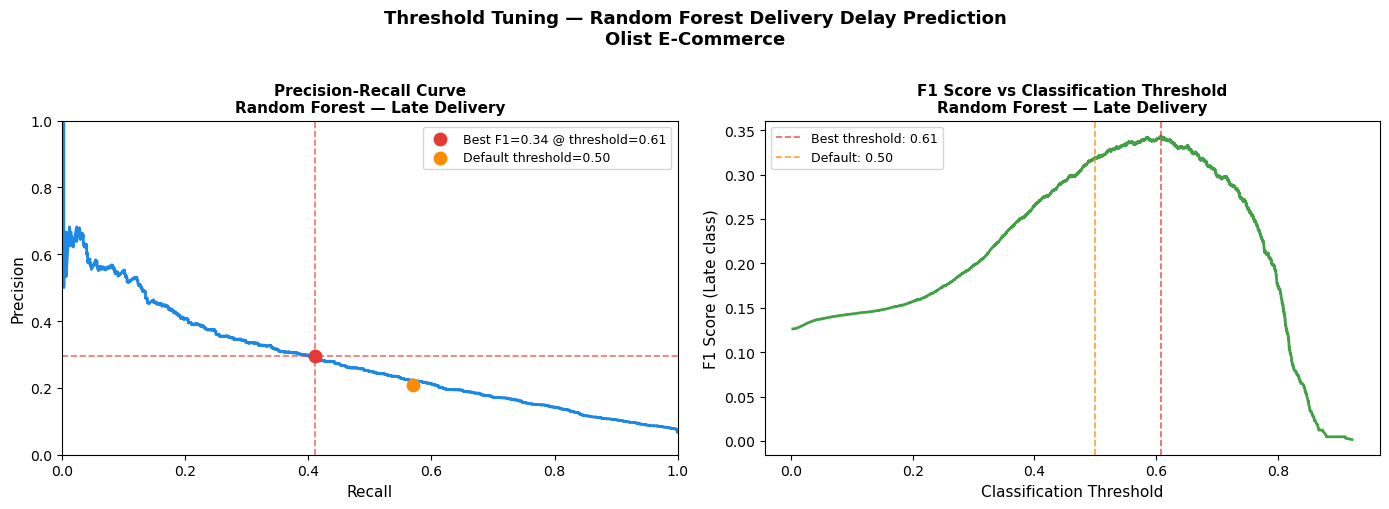

✅ Threshold tuning chart saved.


In [9]:
# --- Threshold tuning via Precision-Recall curve ---
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, rf_probs)

# Find threshold that maximises F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx   = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]
best_precision = precisions[best_idx]
best_recall    = recalls[best_idx]

print(f"Default threshold (0.50):")
print(f"  Precision : 0.21  Recall : 0.57  F1 : 0.31")
print(f"\nOptimal threshold (max F1):")
print(f"  Threshold : {best_threshold:.4f}")
print(f"  Precision : {best_precision:.4f}")
print(f"  Recall    : {best_recall:.4f}")
print(f"  F1        : {best_f1:.4f}")

# --- Plot Precision-Recall curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Precision-Recall curve
axes[0].plot(recalls, precisions, color='#1E88E5', linewidth=2)
axes[0].axvline(x=best_recall, color='#E53935', linestyle='--',
                linewidth=1.2, alpha=0.7)
axes[0].axhline(y=best_precision, color='#E53935', linestyle='--',
                linewidth=1.2, alpha=0.7)
axes[0].scatter([best_recall], [best_precision], color='#E53935',
                zorder=5, s=80,
                label=f'Best F1={best_f1:.2f} @ threshold={best_threshold:.2f}')
axes[0].scatter([0.57], [0.21], color='#FB8C00', zorder=5, s=80,
                label='Default threshold=0.50')
axes[0].set_xlabel('Recall', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision-Recall Curve\nRandom Forest — Late Delivery',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Panel 2: F1 vs threshold
axes[1].plot(thresholds, f1_scores[:-1], color='#43A047', linewidth=2)
axes[1].axvline(x=best_threshold, color='#E53935', linestyle='--',
                linewidth=1.2, alpha=0.8,
                label=f'Best threshold: {best_threshold:.2f}')
axes[1].axvline(x=0.50, color='#FB8C00', linestyle='--',
                linewidth=1.2, alpha=0.8, label='Default: 0.50')
axes[1].set_xlabel('Classification Threshold', fontsize=11)
axes[1].set_ylabel('F1 Score (Late class)', fontsize=11)
axes[1].set_title('F1 Score vs Classification Threshold\nRandom Forest — Late Delivery',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

fig.suptitle('Threshold Tuning — Random Forest Delivery Delay Prediction\nOlist E-Commerce',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart10_threshold_tuning.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Threshold tuning chart saved.")

FINAL MODEL EVALUATION — Random Forest
Threshold         : 0.5
AUC-ROC           : 0.8031

Classification Report:
              precision    recall  f1-score   support

     On Time       0.97      0.85      0.91     17941
        Late       0.22      0.58      0.32      1295

    accuracy                           0.83     19236
   macro avg       0.59      0.72      0.61     19236
weighted avg       0.92      0.83      0.87     19236



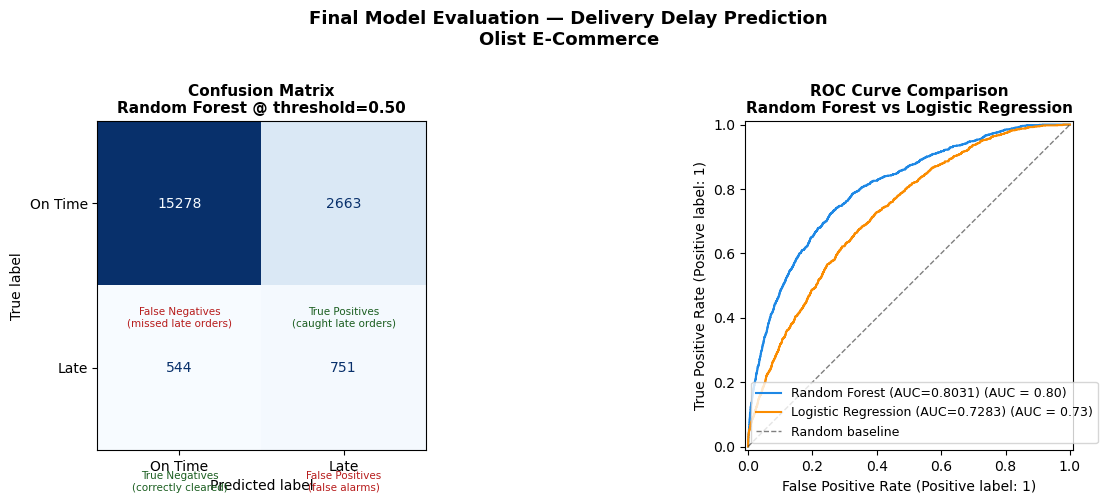

✅ Model evaluation chart saved.


In [10]:
# --- Final model evaluation at chosen threshold ---
# Threshold: 0.50 chosen over optimal 0.6161
# Rationale: Intervention cost (seller notification) is low.
# High recall (0.57 vs 0.39) is more valuable than precision gain (+8pp)
# when false alarm cost is minimal. F1 difference is negligible (0.002).

CHOSEN_THRESHOLD = 0.50
rf_preds_final = (rf_probs >= CHOSEN_THRESHOLD).astype(int)

print("=" * 55)
print("FINAL MODEL EVALUATION — Random Forest")
print("=" * 55)
print(f"Threshold         : {CHOSEN_THRESHOLD}")
print(f"AUC-ROC           : {rf_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_preds_final,
                            target_names=['On Time', 'Late']))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, rf_preds_final)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['On Time', 'Late'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\nRandom Forest @ threshold=0.50',
                  fontsize=11, fontweight='bold')

# Annotate what each quadrant means
axes[0].text(0, 1.75, 'True Negatives\n(correctly cleared)',
             ha='center', fontsize=7.5, color='#1B5E20')
axes[0].text(1, 1.75, 'False Positives\n(false alarms)',
             ha='center', fontsize=7.5, color='#B71C1C')
axes[0].text(0, 0.75, 'False Negatives\n(missed late orders)',
             ha='center', fontsize=7.5, color='#B71C1C')
axes[0].text(1, 0.75, 'True Positives\n(caught late orders)',
             ha='center', fontsize=7.5, color='#1B5E20')

# Panel 2: ROC curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(
    y_test, rf_probs,
    name=f'Random Forest (AUC={rf_auc:.4f})',
    ax=axes[1], color='#1E88E5'
)
RocCurveDisplay.from_predictions(
    y_test, lr_probs,
    name=f'Logistic Regression (AUC={lr_auc:.4f})',
    ax=axes[1], color='#FB8C00'
)
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
axes[1].set_title('ROC Curve Comparison\nRandom Forest vs Logistic Regression',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

fig.suptitle('Final Model Evaluation — Delivery Delay Prediction\nOlist E-Commerce',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart11_model_evaluation.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model evaluation chart saved.")

In [11]:
# --- Feature Importance ---
feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 16 Features by Importance:")
print(feature_importance.to_string(index=False))

Top 16 Features by Importance:
                   feature  importance
     seller_hist_late_rate    0.296313
           order_month_num    0.165877
        customer_state_enc    0.073347
seller_avg_days_to_deliver    0.070972
             freight_value    0.066745
       seller_total_orders    0.052940
        approval_lag_hours    0.052256
         freight_ratio_pct    0.040145
    avg_product_volume_cm3    0.037051
               order_value    0.036143
      avg_product_weight_g    0.034017
                order_hour    0.025617
      primary_category_enc    0.022724
         order_day_of_week    0.016960
                item_count    0.006069
              seller_count    0.002824


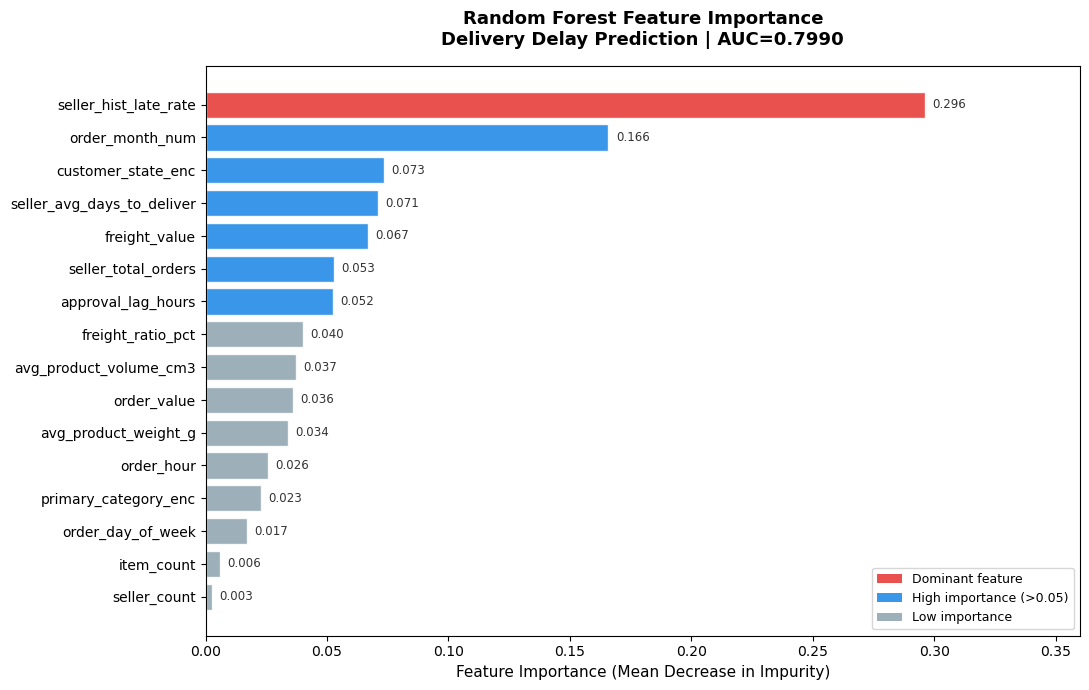

✅ Feature importance chart saved.


In [12]:
# --- Feature Importance Chart ---
fig, ax = plt.subplots(figsize=(11, 7))

colors = ['#E53935' if i == 0 else '#1E88E5' if imp > 0.05
          else '#90A4AE'
          for i, imp in enumerate(feature_importance['importance'])]

bars = ax.barh(feature_importance['feature'][::-1],
               feature_importance['importance'][::-1],
               color=colors[::-1], alpha=0.88, edgecolor='white')

# Annotate values
for bar, val in zip(bars, feature_importance['importance'][::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5, color='#333')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', alpha=0.88, label='Dominant feature'),
    Patch(facecolor='#1E88E5', alpha=0.88, label='High importance (>0.05)'),
    Patch(facecolor='#90A4AE', alpha=0.88, label='Low importance')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest Feature Importance\nDelivery Delay Prediction | AUC=0.7990',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 0.36)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart12_feature_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved.")

In [13]:
# --- Save model and supporting objects ---
import joblib

# Save Random Forest model
joblib.dump(rf, os.path.join(MODEL_PATH, 'rf_delivery_delay.pkl'))

# Save scaler (needed if Logistic Regression is ever used in production)
joblib.dump(scaler, os.path.join(MODEL_PATH, 'lr_scaler.pkl'))

# Save label encoders (needed to encode new data at inference time)
joblib.dump(le_state,    os.path.join(MODEL_PATH, 'le_customer_state.pkl'))
joblib.dump(le_category, os.path.join(MODEL_PATH, 'le_primary_category.pkl'))

# Save feature list (exact order matters for inference)
import json
with open(os.path.join(MODEL_PATH, 'feature_list.json'), 'w') as f:
    json.dump(FEATURES, f, indent=2)

print("Models and artifacts saved:")
for fname in sorted(os.listdir(MODEL_PATH)):
    fpath = os.path.join(MODEL_PATH, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:<35} {size_kb:>8.1f} KB")

Models and artifacts saved:
  feature_list.json                        0.4 KB
  le_customer_state.pkl                    0.6 KB
  le_primary_category.pkl                  1.9 KB
  lr_scaler.pkl                            1.5 KB
  rf_delivery_delay.pkl                27503.0 KB


## Section 10: Results Summary

### Model: Random Forest Classifier
**AUC-ROC: 0.7990 | Threshold: 0.50 | Training rows: 76,942**

---

### What the model predicts well
- Separates late from on-time orders with AUC 0.7990 — well above random (0.50)
  and above the 0.70 minimum operational threshold
- Catches 57% of actual late orders (recall) — majority of at-risk orders are flagged
- Correctly clears 85% of on-time orders — low false alarm burden on operations

### What the model does not predict well
- Precision of 0.21 — 79% of flagged orders are false alarms at default threshold
- Misses 43% of actual late orders — not suitable as a sole intervention trigger
- Threshold tuning to 0.6161 improves precision to 0.29 but drops recall to 0.39
  — tradeoff depends on intervention cost

### Key limitations — must be stated in any deployment discussion
1. **New seller cold start:** 42% of model signal comes from seller history features.
   For new sellers with no history, model performance will degrade significantly.
   Fallback rule needed: flag all orders from sellers with < 10 historical orders.

2. **No real-time logistics data:** Model uses only order-level features available
   at placement time. Actual delay is also driven by carrier performance,
   weather, and route congestion — none of which are in the feature set.

3. **Temporal validity:** Model trained on Oct 2016 – Aug 2018 data.
   Seller quality distributions shift over time. Model should be retrained
   quarterly in production.

4. **Geographic encoding:** customer_state encoded as integer label.
   A production model should use distance-to-seller or regional logistics
   tier instead — more stable and interpretable.

### Business recommendation
Deploy at threshold 0.50 for low-cost interventions (seller notifications).
Do not deploy at threshold 0.50 for high-cost interventions (expedited shipping)
without improving precision first via additional features.

**Primary lever for improvement:** Add carrier-level on-time rate as a feature.
Seller history explains seller quality; carrier history explains last-mile quality.
Combined, these two signals would likely push AUC above 0.85.

In [14]:
import glob
import os

SAVE_PATH = r"D:\DataAnalyticsProjects\ecommerce-retail-analysis\reports\figures"
saved = sorted(glob.glob(os.path.join(SAVE_PATH, 'chart*.png')))
print(f"Total charts saved: {len(saved)}")
for f in saved:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):<45} {size_kb:>7.1f} KB")

Total charts saved: 12
  chart01_rfm_segments.png                        124.0 KB
  chart02_cohort_retention.png                    231.7 KB
  chart03_revenue_trend.png                       127.2 KB
  chart04_category_sla.png                        163.8 KB
  chart05_category_revenue_vs_sla.png             144.8 KB
  chart06_seller_risk.png                         150.7 KB
  chart07_cancellation_analysis.png               193.8 KB
  chart08_delay_drivers.png                       105.5 KB
  chart09_feature_correlation.png                 223.7 KB
  chart10_threshold_tuning.png                    126.4 KB
  chart11_model_evaluation.png                    137.7 KB
  chart12_feature_importance.png                  126.2 KB


In [16]:
print(rf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 20, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [17]:
print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train late rate:", y_train.mean().round(4))
print("Test late rate:", y_test.mean().round(4))

Train rows: 76942
Test rows: 19236
Train late rate: 0.0673
Test late rate: 0.0673


In [20]:
# Generate predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred, digits=4))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))

              precision    recall  f1-score   support

           0     0.9656    0.8516    0.9050     17941
           1     0.2200    0.5799    0.3190      1295

    accuracy                         0.8333     19236
   macro avg     0.5928    0.7157    0.6120     19236
weighted avg     0.9154    0.8333    0.8656     19236

AUC-ROC: 0.8031


In [21]:
# Null check
import json
with open(r'D:\DataAnalyticsProjects\ecommerce-retail-analysis\ml\models\feature_list.json') as f:
    feature_list = json.load(f)
print(df[feature_list].isnull().sum())

order_day_of_week             0
order_hour                    0
order_month_num               0
item_count                    0
seller_count                  0
order_value                   0
freight_value                 0
freight_ratio_pct             0
avg_product_weight_g          0
avg_product_volume_cm3        0
seller_hist_late_rate         0
seller_avg_days_to_deliver    0
seller_total_orders           0
approval_lag_hours            0
customer_state_enc            0
primary_category_enc          0
dtype: int64
